In [34]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [35]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(96, 96)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 96, 96))

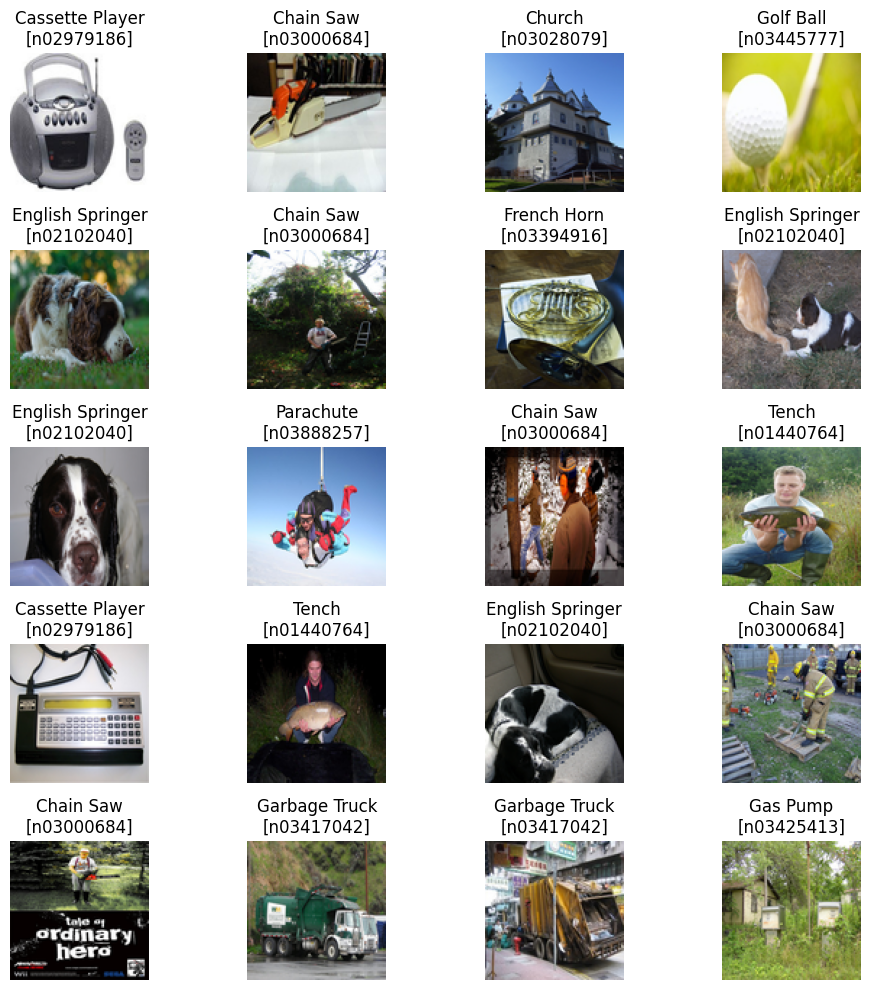

In [36]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10),
    aug_chance=0.5,
    flip_chance=0.5
)

In [37]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(96, 96)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 96, 96))

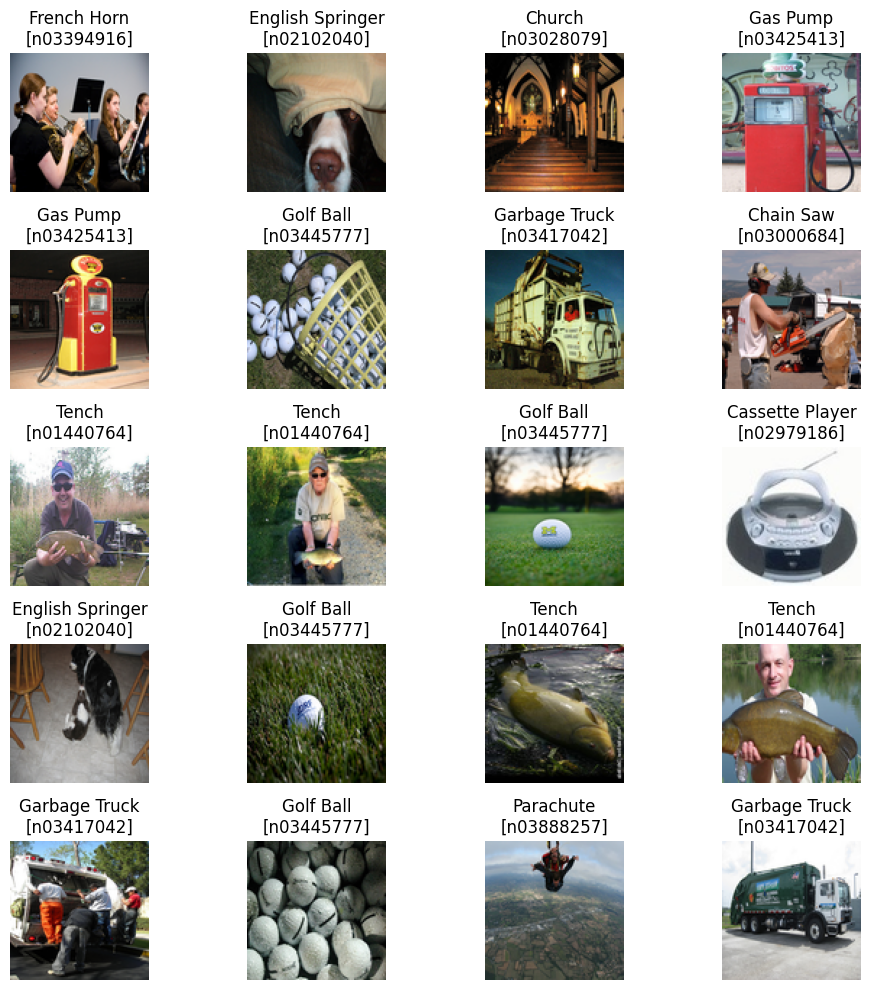

In [38]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10),
    aug_chance=0.5,
    flip_chance=0.5
)

## Building the Model

In [39]:
feature_layers = [
    {"type": "ReLUConv", "num_filters": 16, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 32, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 64, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 2},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Flatten"}
]

warmup_input, _ = train_loader.load_batch(indices=[0], normalize=True)
feature_extractor = Network(layer_definitions=feature_layers)
classifier_input_size = int(feature_extractor.forward(input=warmup_input)[-1].shape[1])

layer_definitions = feature_layers + [
    {"type": "Softmax", "input_size": classifier_input_size, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [40]:
network.describe()

Network Architecture

Layer 1: ReluConvLayer
  Filters Shape: (16, 3, 3, 3) | Biases Shape: (16,)
  Parameters: 448

Layer 2: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 3: ReluConvLayer
  Filters Shape: (32, 16, 3, 3) | Biases Shape: (32,)
  Parameters: 4,640

Layer 4: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 5: ReluConvLayer
  Filters Shape: (64, 32, 3, 3) | Biases Shape: (64,)
  Parameters: 18,496

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: ReluConvLayer
  Filters Shape: (64, 64, 3, 3) | Biases Shape: (64,)
  Parameters: 36,928

Layer 8: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 9: FlattenLayer
  Parameters: 0

Layer 10: SoftmaxLayer
  Weights Shape: (256, 10) | Biases Shape: (10,)
  Parameters: 2,570

Total Parameters: 63,082


In [47]:
print("Input Shape:", warmup_input.shape)
_ = network.forward(input=warmup_input, print_shapes=True)

Input Shape: (1, 3, 96, 96)
Layer 0 Output Shape: (1, 16, 96, 96)
Layer 1 Output Shape: (1, 16, 48, 48)
Layer 2 Output Shape: (1, 32, 48, 48)
Layer 3 Output Shape: (1, 32, 24, 24)
Layer 4 Output Shape: (1, 64, 24, 24)
Layer 5 Output Shape: (1, 64, 12, 12)
Layer 6 Output Shape: (1, 64, 5, 5)
Layer 7 Output Shape: (1, 64, 2, 2)
Layer 8 Output Shape: (1, 256)
Layer 9 Output Shape: (1, 10)


## Building the Train/Eval Loops

In [42]:
def evaluate_model(model, data_loader, batch_size, split_name="Validation"):
    total_loss = 0.0
    correct_predictions = 0
    num_samples = 0
    num_batches = (len(data_loader) + batch_size - 1) // batch_size

    for x_batch, y_batch in data_loader.iter_batches(
        batch_size=batch_size,
        normalize=True,
        one_hot=True,
        shuffle=False
    ):
        outputs = model.forward(input=x_batch)
        y_pred = outputs[-1]

        total_loss += model.cce_loss(y_pred=y_pred, y_true=y_batch).item()

        predicted_labels = cp.argmax(y_pred, axis=1)
        true_labels = cp.argmax(y_batch, axis=1)

        correct_predictions += cp.sum(predicted_labels == true_labels).item()
        num_samples += x_batch.shape[0]

    avg_loss = total_loss / num_batches
    accuracy = correct_predictions / num_samples

    return avg_loss, accuracy

In [48]:
def train_model(model, train_loader, test_loader, batch_size=16, epochs=10, base_learning_rate=0.003, min_learning_rate=0.0001):
    train_num_batches = (len(train_loader) + batch_size - 1) // batch_size
    total_steps = epochs * train_num_batches
    global_step = 0

    best_model = model
    best_model_accuracy = 0.0

    for epoch in range(epochs):
        total_loss = 0.0

        for batch_idx, (x_batch, y_batch) in enumerate(
            train_loader.iter_batches(
                batch_size=batch_size, 
                normalize=True, 
                one_hot=True, 
                shuffle=True, 
                aug_chance=0.5, 
                flip_chance=0.5
            ), start=1
        ):
            learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

            outputs = model.forward(input=x_batch)
            y_pred = outputs[-1]

            error = y_pred - y_batch
            loss = model.cce_loss(y_pred=y_pred, y_true=y_batch).item()
            total_loss += loss

            model.backward(output_error=error, batch_size=x_batch.shape[0])
            model.update_parameters(learning_rate=learning_rate)

            global_step += 1

        train_loss = total_loss / train_num_batches
        test_loss, test_accuracy = evaluate_model(
            model=model, 
            data_loader=test_loader, 
            batch_size=batch_size, 
            split_name="Validation"
        )

        if test_accuracy > best_model_accuracy:
            best_model = model
            best_model_accuracy = test_accuracy
        
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} | Test Accuracy: {test_accuracy:.4f}")
    
    return best_model

## Training the Model

In [44]:
batch_size = 16
epochs = 30
base_learning_rate = 0.01
min_learning_rate = 0.0001

best_model = train_model(
    model=network,
    train_loader=train_loader,
    test_loader=test_loader,
    batch_size=batch_size,
    epochs=epochs,
    base_learning_rate=base_learning_rate,
    min_learning_rate=min_learning_rate
)

Epoch 1/30 | Train Loss: 1.968802 | Test Loss: 1.657846 | Test Accuracy: 0.4324
Epoch 2/30 | Train Loss: 1.590363 | Test Loss: 1.624731 | Test Accuracy: 0.4614
Epoch 3/30 | Train Loss: 1.422513 | Test Loss: 1.387394 | Test Accuracy: 0.5394
Epoch 4/30 | Train Loss: 1.327453 | Test Loss: 1.379296 | Test Accuracy: 0.5396
Epoch 5/30 | Train Loss: 1.255026 | Test Loss: 1.233681 | Test Accuracy: 0.5845
Epoch 6/30 | Train Loss: 1.193742 | Test Loss: 1.184384 | Test Accuracy: 0.6148
Epoch 7/30 | Train Loss: 1.126744 | Test Loss: 1.164282 | Test Accuracy: 0.6260
Epoch 8/30 | Train Loss: 1.071808 | Test Loss: 1.211606 | Test Accuracy: 0.6036
Epoch 9/30 | Train Loss: 1.036716 | Test Loss: 1.123557 | Test Accuracy: 0.6382
Epoch 10/30 | Train Loss: 1.005824 | Test Loss: 1.062875 | Test Accuracy: 0.6540
Epoch 11/30 | Train Loss: 0.963468 | Test Loss: 1.120308 | Test Accuracy: 0.6438
Epoch 12/30 | Train Loss: 0.933648 | Test Loss: 1.135820 | Test Accuracy: 0.6428
Epoch 13/30 | Train Loss: 0.909501 | 

## Evaluating the Model

In [45]:
train_loss, train_accuracy = evaluate_model(
    model=best_model, 
    data_loader=train_loader, 
    batch_size=batch_size, 
    split_name="Train"
)

print(f"Final Train Loss: {train_loss:.6f} | Final Train Accuracy: {train_accuracy:.4f}")

Final Train Loss: 0.516509 | Final Train Accuracy: 0.8395


In [46]:
test_loss, test_accuracy = evaluate_model(
    model=best_model, 
    data_loader=test_loader, 
    batch_size=batch_size, 
    split_name="Test"
)

print(f"Final Test Loss: {test_loss:.6f} | Final Test Accuracy: {test_accuracy:.4f}")

Final Test Loss: 0.984401 | Final Test Accuracy: 0.7001
